In [19]:
import pandas as pd

# List of years and filenames
years = [2009, 2010, 2011]
files = ["2009.csv", "2010.csv", "2011.csv"]

# Dictionary to store DataFrames labeled by disease
disease_dataframes = {}

# Process each file and organize by disease
for year, file in zip(years, files):
    df = pd.read_csv(file, index_col="Resident County")  # Set county as index
    
    # Convert all values to numeric to prevent string-related errors
    df = df.apply(pd.to_numeric, errors="coerce")
    
    # Get total deaths for each county
    total_deaths = df["Total Deaths"]
    
    # Drop "Total Deaths" column since we're using it for calculations
    df.drop(columns=["Total Deaths"], inplace=True)

    # Iterate through diseases and store their rates
    for disease in df.columns:
        if disease not in disease_dataframes:
            disease_dataframes[disease] = pd.DataFrame()
        
        # Compute rate = deaths per cause / total deaths
        df_year = df[disease].div(total_deaths, axis=0)
        df_year.name = year  # Label column with year
        disease_dataframes[disease] = disease_dataframes[disease].join(df_year, how="outer")

# Save each disease's table as separate CSVs (optional)
for disease, df in disease_dataframes.items():
    df.to_csv(f"{disease}_death_rates.csv")

print("Death rates successfully calculated for each cause of death!")

Death rates successfully calculated for each cause of death!


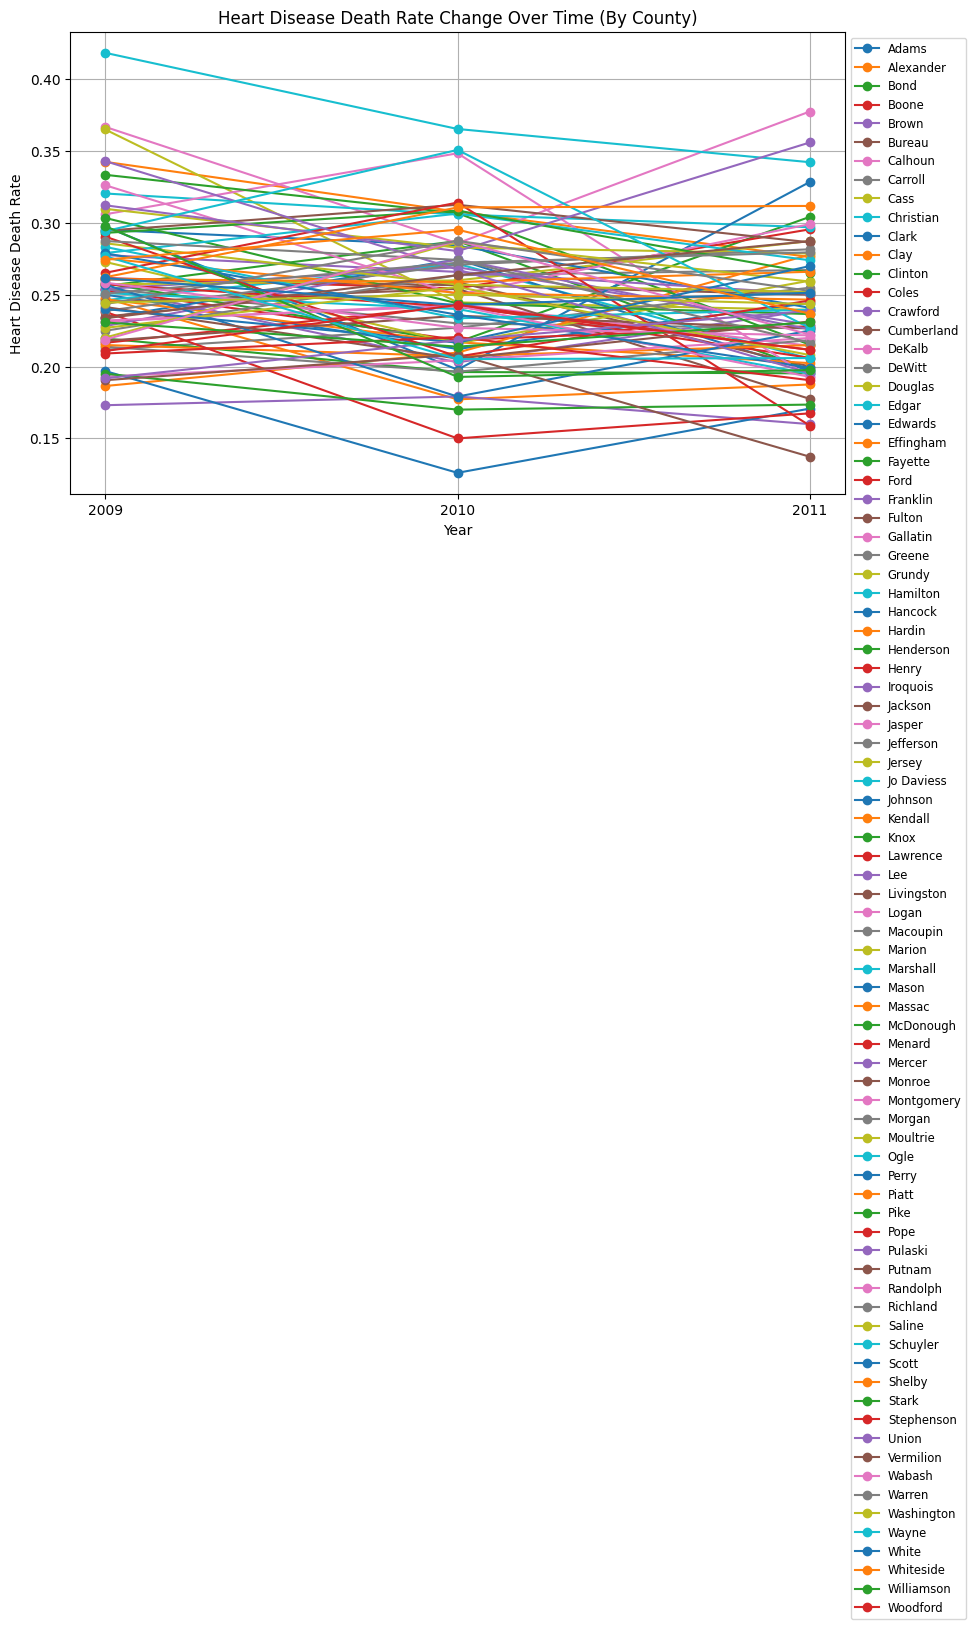

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df_heart = pd.read_csv("heart_death.csv").dropna()

# Extract counties and years
counties = df_heart["Resident County"]
years = ["2009", "2010", "2011"]

# Create plot
plt.figure(figsize=(10, 6))

# Loop through each county to plot its trend
for index, row in df_heart.iterrows():
    plt.plot(years, row[years], marker="o", label=row["Resident County"])

# Customize plot
plt.xlabel("Year")
plt.ylabel("Heart Disease Death Rate")
plt.title("Heart Disease Death Rate Change Over Time (By County)")
plt.legend(fontsize="small", loc="best", bbox_to_anchor=(1,1))
plt.grid(True)

# Show plot
plt.show()

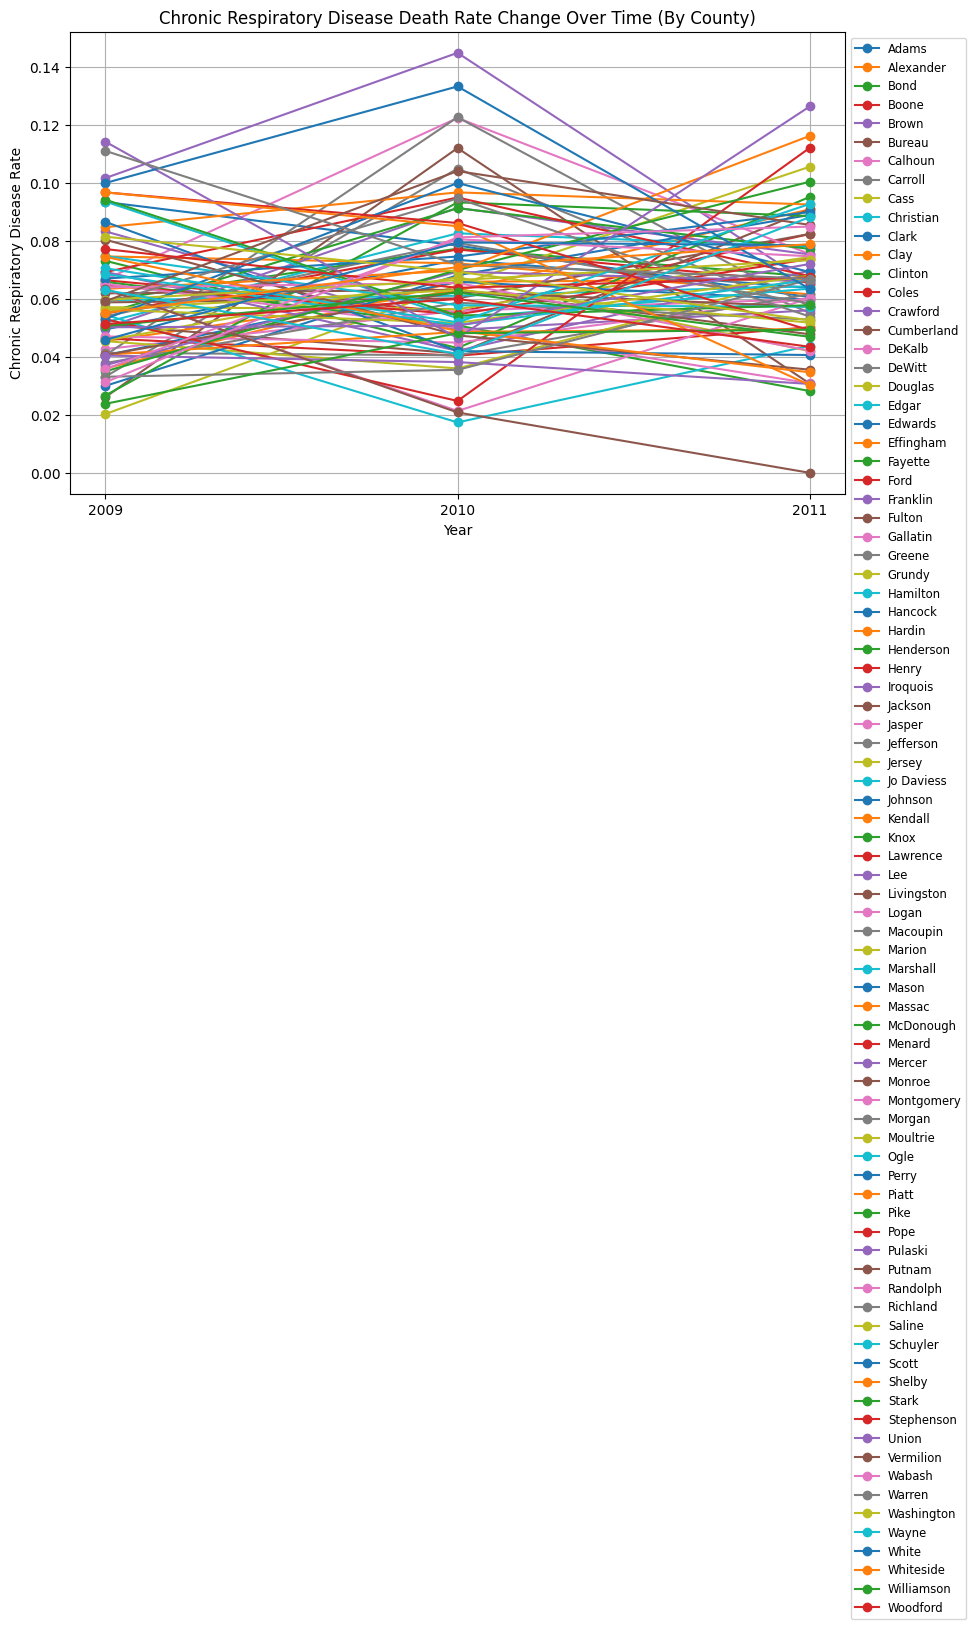

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df_resp = pd.read_csv("respiratorydiseases_death_rates.csv").dropna()

# Extract counties and years
counties = df_resp["Resident County"]
years = ["2009", "2010", "2011"]

# Create plot
plt.figure(figsize=(10, 6))

# Loop through each county to plot its trend
for index, row in df_resp.iterrows():
    plt.plot(years, row[years], marker="o", label=row["Resident County"])

# Customize plot
plt.xlabel("Year")
plt.ylabel("Chronic Respiratory Disease Rate")
plt.title("Chronic Respiratory Disease Death Rate Change Over Time (By County)")
plt.legend(fontsize="small", loc="best", bbox_to_anchor=(1,1))
plt.grid(True)

# Show plot
plt.show()

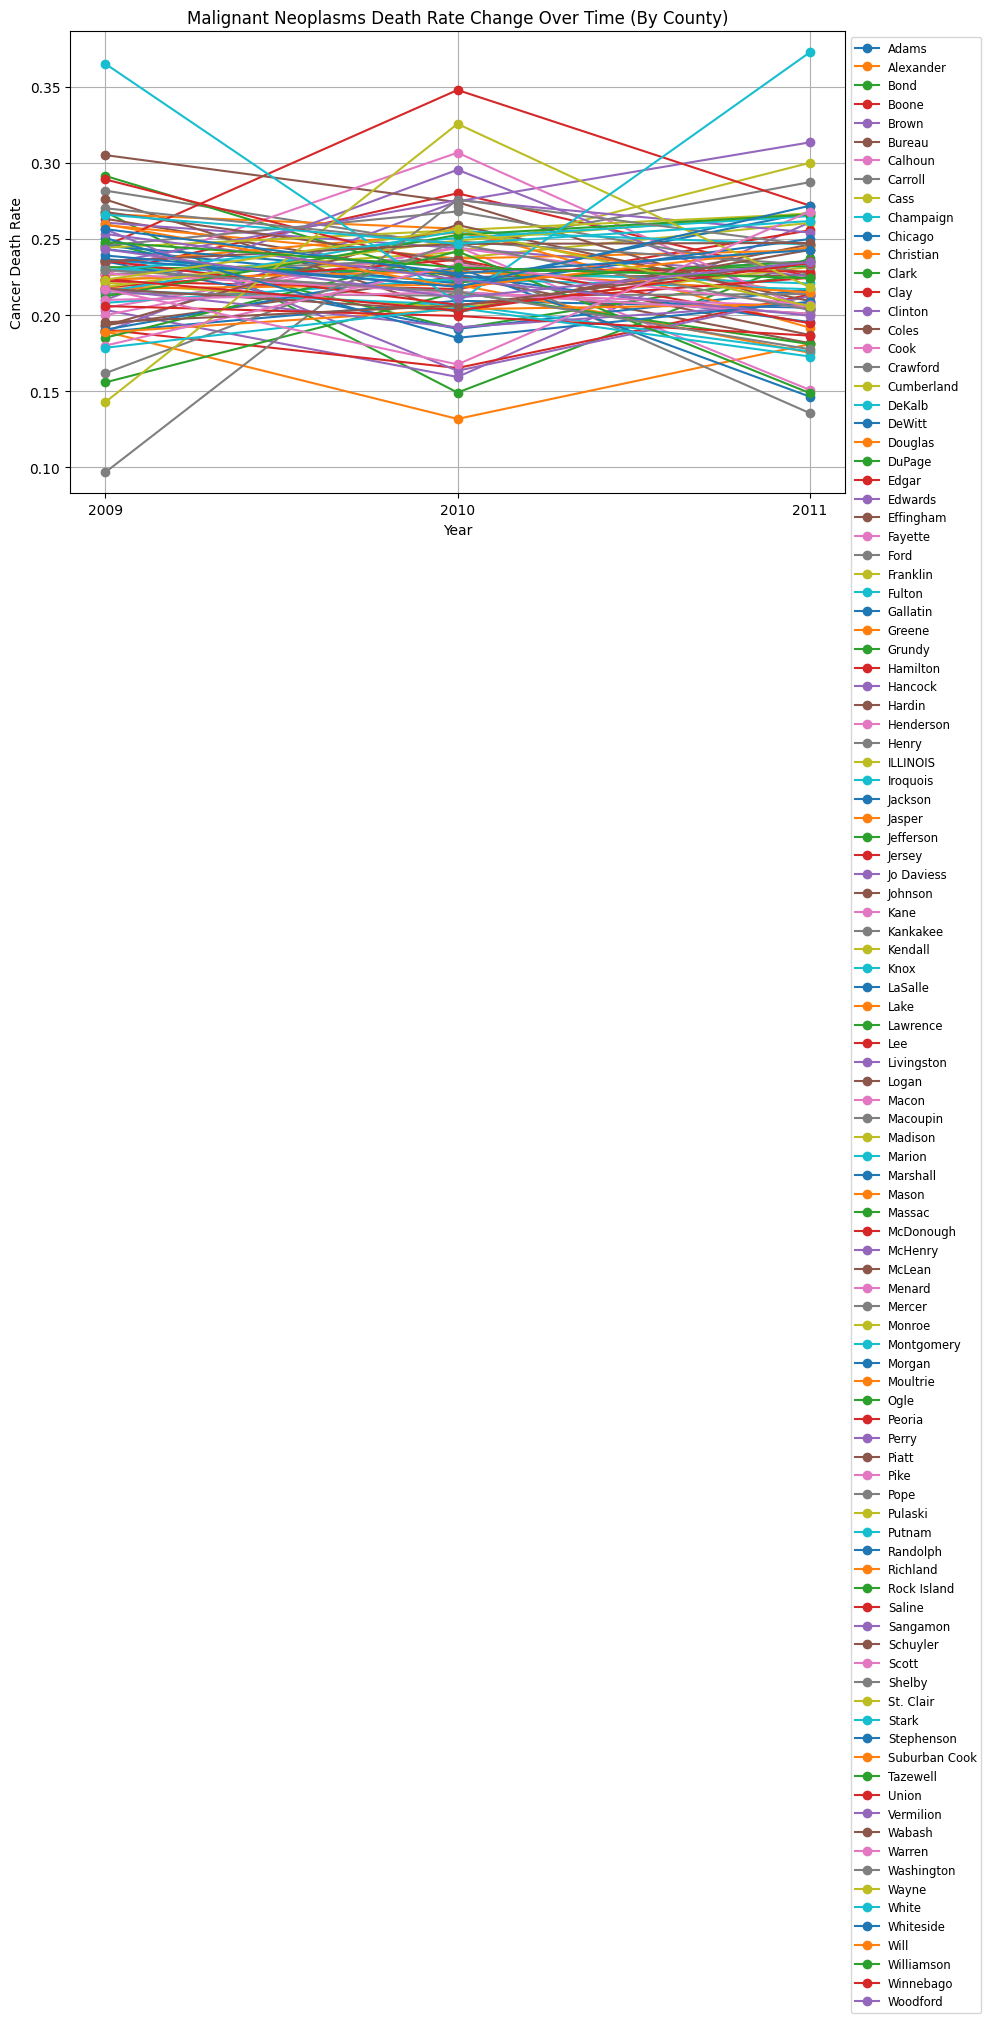

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the malignant neoplasms death rate dataset
df_cancer = pd.read_csv("Malignant neoplasms_death_rates.csv")

# Extract years from columns (excluding county name)
years = df_cancer.columns[1:]

# Create plot
plt.figure(figsize=(10, 6))

# Loop through each county to plot its trend
for index, row in df_cancer.iterrows():
    plt.plot(years, row[years], marker="o", label=row["Resident County"])

# Customize plot
plt.xlabel("Year")
plt.ylabel("Cancer Death Rate")
plt.title("Malignant Neoplasms Death Rate Change Over Time (By County)")
plt.legend(fontsize="small", loc="best", bbox_to_anchor=(1,1))
plt.grid(True)

# Show plot
plt.show()

In [23]:
Cancer2009 = df_cancer["2009"].mean()
Cancer2009
Cancer2010 = df_cancer["2010"].mean()
Cancer2010
Cancer2011 = df_cancer["2011"].mean()
Cancer2011


np.float64(0.22435758903662437)

In [27]:
heart2011 = df_heart["2009"].mean()
heart2011


np.float64(0.2591234936903197)